# Topic Modeling

Topic extraction and clustering from text data.

In [3]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

In [4]:
import pandas as pd

df = pd.read_csv("../data/processed/reviews_with_sentiment.csv")
print(df.shape)
df[["final_text", "language", "sentiment_label"]].head(3)

(5946, 10)


,final_text,language,sentiment_label
0,chambre confortable decoration peu demodee. pe...,fr,neutral
1,spa propose traitement signature exclusif deve...,fr,positive
2,sejour correct qui ne justifie pas_pleinement ...,fr,neutral


In [5]:
df_tm = df.copy()
df_tm["final_text"] = df_tm["final_text"].fillna("").astype(str)

df_tm = df_tm[df_tm["final_text"].str.split().str.len() >= 3].reset_index(drop=True)
print(df_tm.shape)

(5946, 10)


In [6]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

texts = df_tm["final_text"].tolist()
DOMAIN_STOP = {
    "hotel","promenade","ottawa","room","rooms","chambre","chambres",
    "stay","stayed","la","en","que","qui","sont","etait"
}
vectorizer = CountVectorizer(
    min_df=5,        # ignore very rare words
    max_df=0.85,
    stop_words = list(DOMAIN_STOP)    # ignore overly common words
)
X = vectorizer.fit_transform(texts)

n_topics = 8
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)
lda.fit(X)

LatentDirichletAllocation(n_components=8, random_state=42)

In [7]:
import numpy as np

words = np.array(vectorizer.get_feature_names_out())

def print_topics(model, topn=12):
    for i, topic in enumerate(model.components_):
        top_words = words[np.argsort(topic)[-topn:]][::-1]
        print(f"\nTopic {i+1}: " + ", ".join(top_words))

print_topics(lda, topn=12)


Topic 1: service, old, lobby, great, suite, staff, bar, like, history, beautiful, experience, hotels

Topic 2: no, night, did, check, service, just, time, staff, it, in, bathroom, lobby

Topic 3: great, location, parliament, staff, good, market, byward, street, hill, just, clean, rideau

Topic 4: personnel, vue, rideau, service, notre, canal, exclusive, quelques, deco, fois, plutot, sejour

Topic 5: bien, situe, peu, tout, ne, est, meme, petit, prix, personnel, bon, avons

Topic 6: son, experience, luxe, prix, bain, salle, etablissement, collection, correct, rare, petit, service

Topic 7: service, spa, restaurant, malgre, parfois, suite, offers, cuisine, gastronomique, private, experience, propose

Topic 8: staff, good, clean, check, great, no, location, small, friendly, comfortable, helpful, bathroom


In [8]:
import numpy as np

# doc-topic distribution
doc_topic = lda.transform(X)  # shape: (n_docs, n_topics)
df_tm["topic_id"] = doc_topic.argmax(axis=1) + 1  # 1..8
df_tm["topic_conf"] = doc_topic.max(axis=1)

# sentiment distribution per topic
topic_sent = (
    df_tm.groupby("topic_id")["sentiment_label"]
    .value_counts(normalize=True)
    .rename("pct")
    .reset_index()
)

topic_sent.sort_values(["topic_id", "pct"], ascending=[True, False])

,topic_id,sentiment_label,pct
0,1,positive,0.820567
1,1,neutral,0.111228
2,1,negative,0.068206
3,2,negative,0.459988
4,2,positive,0.362248
5,2,neutral,0.177764
6,3,positive,0.895250
7,3,neutral,0.079375
8,3,negative,0.025374
9,4,positive,0.708738


In [9]:
topic_sent

,topic_id,sentiment_label,pct
0,1,positive,0.820567
1,1,neutral,0.111228
2,1,negative,0.068206
3,2,negative,0.459988
4,2,positive,0.362248
5,2,neutral,0.177764
6,3,positive,0.895250
7,3,neutral,0.079375
8,3,negative,0.025374
9,4,positive,0.708738


**Embeddings**

In [11]:
import numpy as np

topics, probs = topic_model.fit_transform(texts, embeddings)

df_tm["topic_emb_id"] = topics

# confidence-like score (robust)
if probs is None:
    df_tm["topic_emb_conf"] = np.nan
elif isinstance(probs, np.ndarray) and probs.ndim == 1:
    # already a single score per doc
    df_tm["topic_emb_conf"] = probs
else:
    # probs is (n_docs, n_topics)
    df_tm["topic_emb_conf"] = probs.max(axis=1)

In [12]:
topic_sent_emb = (
    df_tm[df_tm["topic_emb_id"] != -1]
    .groupby("topic_emb_id")["sentiment_label"]
    .value_counts(normalize=True)
    .rename("pct")
    .reset_index()
)
topic_sent_emb.sort_values(["topic_emb_id","pct"], ascending=[True, False]).head(30)

,topic_emb_id,sentiment_label,pct
0,0,positive,0.702047
1,0,negative,0.178692
2,0,neutral,0.119261
3,1,positive,0.713198
4,1,neutral,0.192893
5,1,negative,0.093909
6,2,positive,0.545198
7,2,neutral,0.234463
8,2,negative,0.220339
9,3,negative,0.575000


**Topic Insights**

**🟢 Major Strengths**

**Topic 3 – Location Advantage**

(89.5% positive)

The hotel’s proximity to Parliament, ByWard Market, and Rideau Canal is the strongest satisfaction driver. Location is a clear competitive advantage and core marketing asset.

**Topic 8 – Room Comfort & Staff Quality**

(85.6% positive)

Cleanliness, staff friendliness, and overall comfort consistently receive high praise. Frontline service quality is a key operational strength.

**Topic 1 – Heritage & Lobby Experience**

(82.1% positive)

Guests value the hotel’s historic character and lobby atmosphere, reinforcing brand identity and differentiation.

**🟡 Mixed / Secondary Strength Areas**

**Topic 7 – Spa & Restaurant Experience**

(61.4% positive, 18.8% negative)

While generally appreciated, satisfaction is less consistent compared to core services, suggesting opportunity for service refinement.

**Topic 4 – French Reviews: View & Decor**

(70.9% positive)

French-language reviews emphasize views and decor. Slightly lower positivity may reflect tone differences or service perception nuances.

**Topic 5 – French Reviews: Value & Room Size**

(70.3% positive, 13.7% negative)

Feedback suggests occasional concerns regarding room size and price-value alignment.

**🔴 Operational Risk Areas**

**Topic 2 – Check-in & Night Service Issues**

(46% negative)

This is the most critical dissatisfaction cluster. Complaints focus on check-in experience, bathroom conditions, and certain service interactions. This area should be prioritized for operational review.

**Topic 6 – Luxury Positioning vs Price Perception**

(23.6% negative, 32.5% neutral)


**Strategic Summary**

Core strengths: Location, staff quality, cleanliness, heritage atmosphere

Operational priority: Check-in process and bathroom-related complaints

Strategic consideration: Align luxury positioning with price perception

Language insight: French reviews show slightly more critical tone


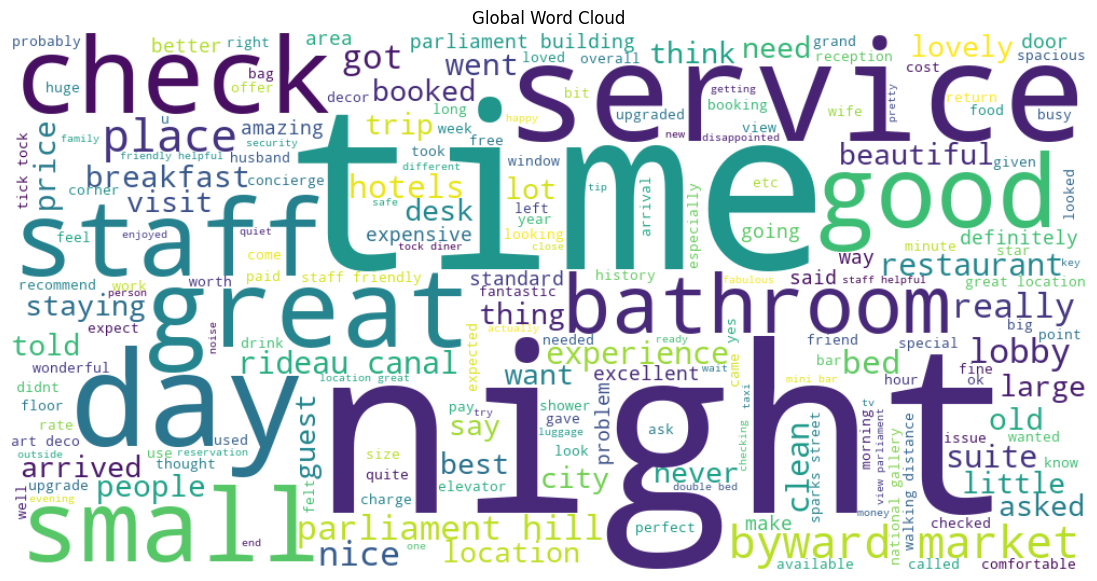

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from wordcloud import STOPWORDS

DOMAIN_STOP = {
    "hotel","promenade","ottawa","room","rooms",
    "chambre","chambres","stay","stayed",
    "la","en","que","qui","sont","etait"
}

custom_stopwords = set(STOPWORDS).union(DOMAIN_STOP)

text_all = " ".join(df_tm["final_text"])

wc_all = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis",
    stopwords = custom_stopwords
).generate(text_all)

plt.figure(figsize=(14,7))
plt.imshow(wc_all, interpolation="bilinear")
plt.axis("off")
plt.title("Global Word Cloud")
plt.show()

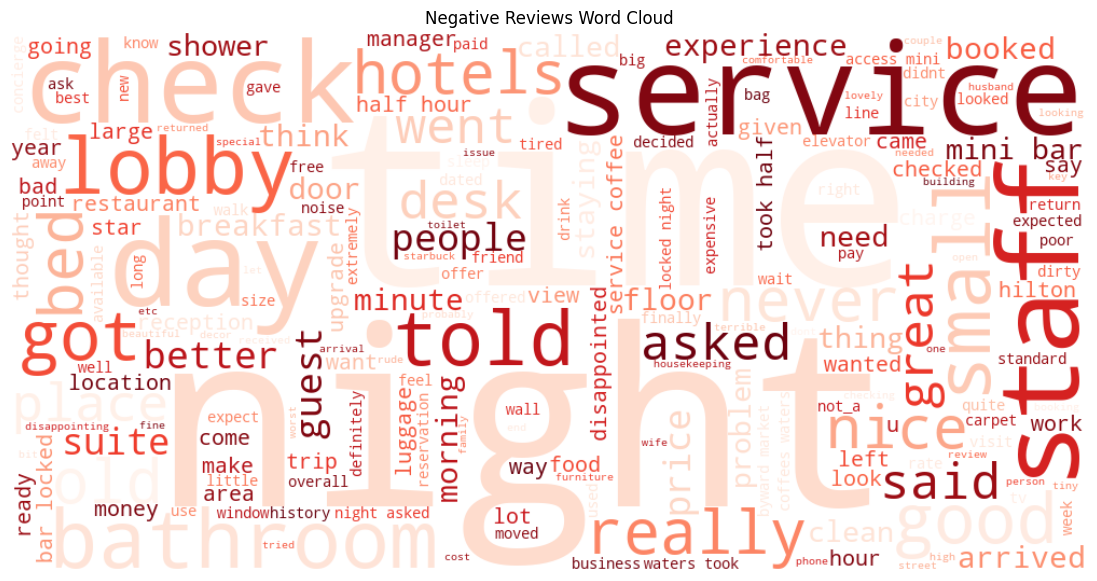

In [ ]:
# negative reviews
neg_text = " ".join(
    df_tm[df_tm["sentiment_label"] == "negative"]["final_text"]
)

wc_neg = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="Reds",
    stopwords = custom_stopwords
).generate(neg_text)

plt.figure(figsize=(14,7))
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show() 

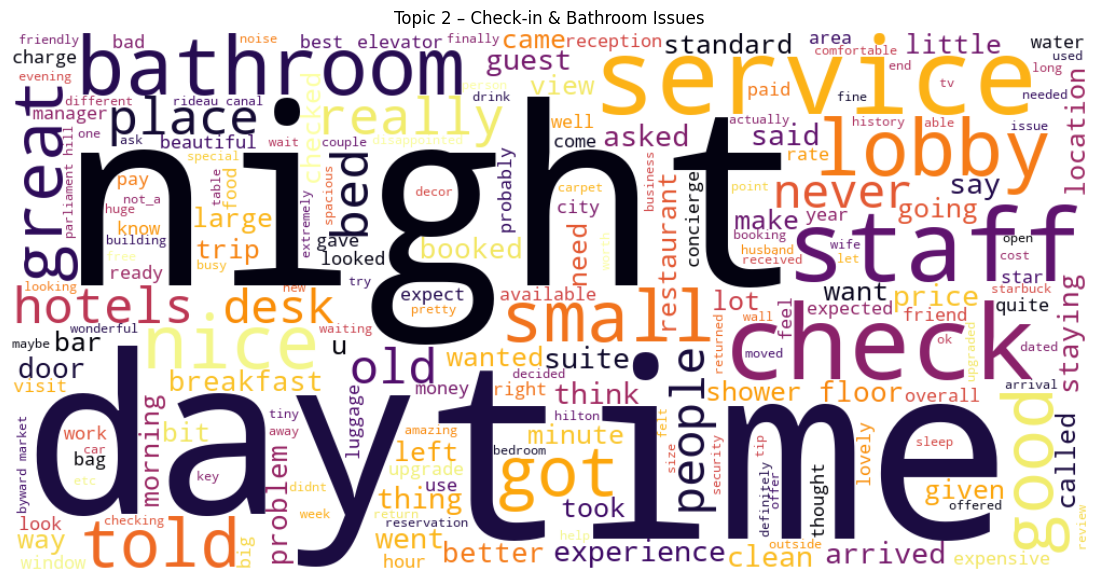

In [ ]:
# Topic 2 : Main risk area 
topic2_text = " ".join(
    df_tm[df_tm["topic_id"] == 2]["final_text"]
)

wc_t2 = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="inferno",
    stopwords= custom_stopwords
).generate(topic2_text)

plt.figure(figsize=(14,7))
plt.imshow(wc_t2, interpolation="bilinear")
plt.axis("off")
plt.title("Topic 2 – Check-in & Bathroom Issues")
plt.show()